<a href="https://colab.research.google.com/github/honestfarmer-cod/avcad/blob/main/Exercise4_Univariate_Exploratory_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 4 – Univariate Exploratory Data Analysis (EFIplus_medit)

In this exercise you will work with the EFIplus_medit dataset to explore how environmental variables relate to the presence of *Salmo trutta fario* (Brown Trout) and to practice assessing normality and the Central Limit Theorem.  

We will answer four main questions:

1. How does Mean Annual Temperature (`temp_ann`) relate to the presence of Brown Trout?
2. Is this temperature–presence relationship similar in the **Minho** and **Tagus (Tejo)** catchments, and how do the “effect sizes” compare?
3. Does `Actual_river_slope` follow a normal distribution?
4. What happens to the distribution of sample means of `Actual_river_slope` when we repeatedly resample and average (Central Limit Theorem)?


## 0. Data loading and basic cleaning

In this first step we load the EFIplus_medit dataset from the zip file, drop some unused columns, rename the total fish column, and remove rows with missing values.  

We also create a simple analysis dataframe with only `temp_ann` and Brown Trout presence, and recode the species column to a clearer categorical variable.


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Temperature and Brown Trout presence (whole dataset)

**Goal:** Explore how mean annual temperature (`temp_ann`) is associated with the presence of Brown Trout across all sites.

Steps:
- Use `df_analysis` (with `temp_ann` and `Brown_Trout_Presence`) as the working dataset.
- Visualize the distribution of `temp_ann` for sites where Brown Trout is present vs absent, for example using a boxplot or violin plot.
- Briefly describe the pattern: do Brown Trout tend to occur at cooler or warmer sites, and is there strong overlap between the distributions?


In [5]:
import pandas as pd

# Load the dataset (from VJ4jLdBmkvSY)
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/EFIplus_medit (1).zip', compression='zip', sep=";")

# Clean up the dataset (from tSmr-uorkvSZ)
df.drop(df.iloc[:,5:15], axis=1, inplace=True)
df.rename(columns={'Sum of Run1_number_all':'Total_fish_individuals'}, inplace=True)
df.columns = list(map(str, df.columns))

# Handle missing data by dropping rows with any NaN values (from SsbzbkQLkvSZ)
df2 = df.dropna()

# Subtask: Select columns, rename, and convert to categorical
df_analysis = df2[['temp_ann', 'Salmo trutta fario']].copy()
df_analysis.rename(columns={'Salmo trutta fario': 'Brown_Trout_Presence'}, inplace=True)
df_analysis['Brown_Trout_Presence'] = df_analysis['Brown_Trout_Presence'].astype('category')

print(df_analysis.head())
print(df_analysis.info())

    temp_ann Brown_Trout_Presence
18       9.3                    1
19      10.4                    1
28      12.6                    0
32      11.2                    1
43      11.1                    0
<class 'pandas.core.frame.DataFrame'>
Index: 2822 entries, 18 to 5010
Data columns (total 2 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   temp_ann              2822 non-null   float64 
 1   Brown_Trout_Presence  2822 non-null   category
dtypes: category(1), float64(1)
memory usage: 47.0 KB
None


## 2. Minho vs Tagus catchments: effect of temperature on Brown Trout

Here we repeat the temperature–presence analysis **separately** for the Minho and Tagus (Tejo) catchments and compare “effect sizes”.

We will:

1. Create filtered dataframes for the two catchments:
   - `df_minho`: rows where `Catchment_name == "Minho"`.
   - `df_tagus`: rows where `Catchment_name == "Tejo"` (this is the Tagus catchment in the dataset).

2. For each catchment:
   - Visualize `temp_ann` for presence (1) and absence (0) of Brown Trout using boxplots (or violin plots).
   - Perform an independent-samples t-test comparing mean `temp_ann` between presence and absence groups.
   - Compute an effect size (Cohen’s d) to quantify how strong the temperature difference is.

3. Compare effect sizes:
   - Report the Cohen’s d for Minho and for Tagus.
   - Comment on which catchment shows a stronger temperature–presence relationship and whether the direction is the same.

The next code cell prepares the processed dataframe with `Brown_Trout_Presence` and builds `df_minho` and `df_tagus`.


In [11]:
df_processed = df2.copy()
df_processed.rename(columns={'Salmo trutta fario': 'Brown_Trout_Presence'}, inplace=True)
df_processed['Brown_Trout_Presence'] = df_processed['Brown_Trout_Presence'].astype('category')

df_minho = df_processed[df_processed['Catchment_name'] == 'Minho'].copy()
df_tagus = df_processed[df_processed['Catchment_name'] == 'Tejo'].copy()

print("Minho Catchment Data (df_minho.head()):")
print(df_minho.head())
print("\nTagus Catchment Data (df_tagus.head()):")
print(df_tagus.head())

Minho Catchment Data (df_minho.head()):
       Site_code   Latitude  Longitude Country Catchment_name  \
1759  ES_35_0562  43.250639  -7.320337   Spain          Minho   
1760  ES_35_0563  43.261115  -7.371032   Spain          Minho   
1761  ES_35_0564  43.258076  -7.398143   Spain          Minho   
1762  ES_35_0565  43.240407  -7.435728   Spain          Minho   
1763  ES_35_0566  43.206242  -7.439544   Spain          Minho   

     Water_source_type Flow_regime  Altitude Geological_typology  \
1759           Pluvial   Permanent       450          Calcareous   
1760           Pluvial   Permanent       430           Siliceous   
1761           Pluvial   Permanent       425           Siliceous   
1762           Pluvial   Permanent       415           Siliceous   
1763           Pluvial   Permanent       405           Siliceous   

      Actual_river_slope  ...  Squalius malacitanus  Squalius pyrenaicus  \
1759                3.19  ...                     0                    0   
1760    

### 2.1 Check catchment names

Before relying on the filtered dataframes, we quickly inspect the unique values in `Catchment_name` to confirm how the Tagus catchment is coded in the dataset (e.g. `"Tejo"` instead of `"Tagus"`).  

This avoids creating empty dataframes due to spelling differences.


In [7]:
print("Unique Catchment Names in df2:")
print(df2['Catchment_name'].unique())


Unique Catchment Names in df2:
['Douro' 'Segura' 'Jucar' 'Tejo' 'Ebro' 'Cantabrica' 'Galiza-Norte'
 'Minho' 'Galiza-Sul' 'Catala' 'Guadalquivir' 'Sur' 'Campania-South'
 'Saline-Pescara-Sangro' 'Tevere' 'Guadia' 'Oeste' 'Mira' 'Mondego'
 'Odelouca' 'Algarve-Sotavento' 'Algarve-barlavento' 'Sado' 'Tejo-Sado'
 'Vouga' 'EntreDouroeVouga' 'Vouga-Mondego']


### 2.2 Effect sizes for Minho and Tagus

In this step we:

- Split each catchment into Brown Trout **absence (0)** and **presence (1)** groups.
- Create boxplots of `temp_ann` by `Brown_Trout_Presence`.
- Run Welch’s t-test (independent samples t-test with unequal variances).
- Compute Cohen’s d for each catchment as a standardized effect size.

At the end, we print and interpret both effect sizes side by side to see where temperature seems more strongly related to Brown Trout presence.



--- Analysis for Minho Catchment ---


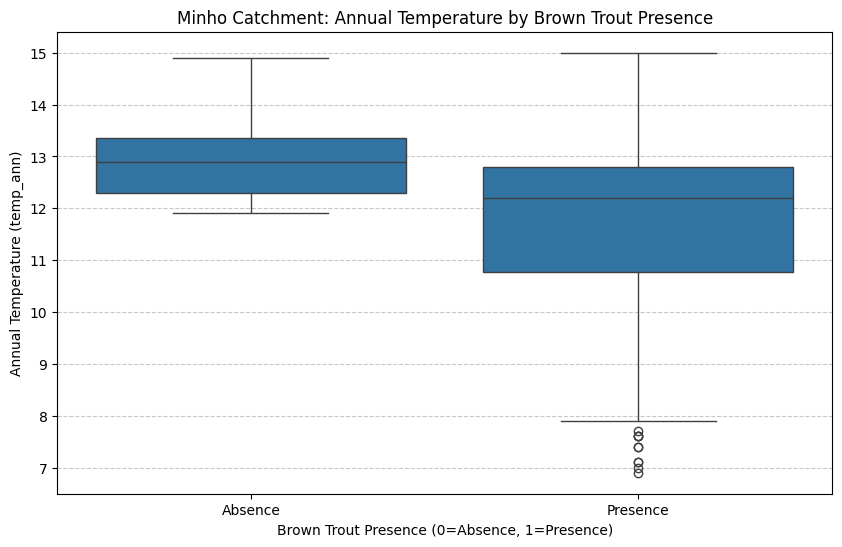

Minho Catchment T-test: t-statistic = 4.3496, p-value = 0.0011
Minho Catchment Cohen's d: -0.7016

--- Analysis for Tagus (Tejo) Catchment ---


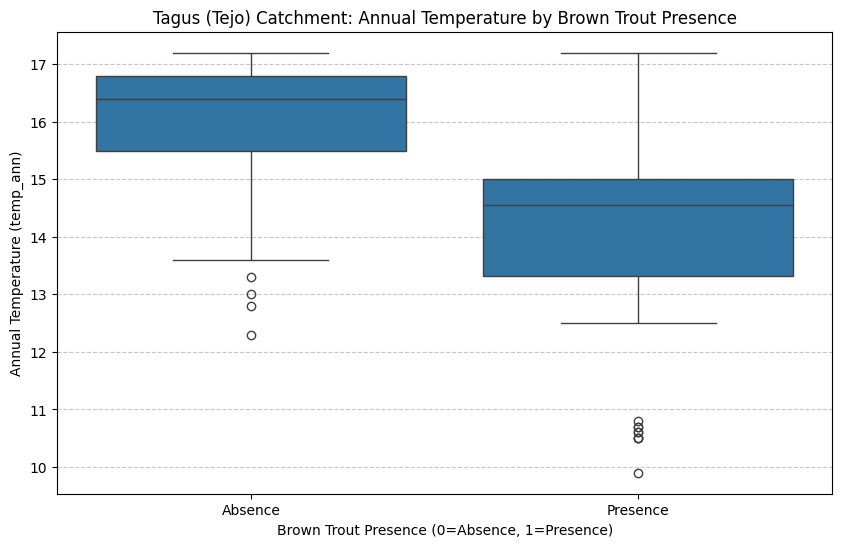

Tagus Catchment T-test: t-statistic = 7.6896, p-value = 0.0000
Tagus Catchment Cohen's d: -1.8441

--- Comparison of Effect Sizes (Cohen's d) ---
Minho Catchment Cohen's d: -0.7016
Tagus Catchment Cohen's d: -1.8441

Interpretation:
The effect of annual temperature on brown trout presence/absence appears stronger in the Tagus catchment compared to the Minho catchment.
Note: Cohen's d values indicate the standardized difference between means. Generally, d=0.2 is considered small, d=0.5 medium, and d=0.8 large.


In [12]:
print("\n--- Analysis for Minho Catchment ---")
# 1a. Separate temp_ann values for Minho catchment
minho_absence_temp = df_minho[df_minho['Brown_Trout_Presence'] == 0]['temp_ann']
minho_presence_temp = df_minho[df_minho['Brown_Trout_Presence'] == 1]['temp_ann']

# Check if groups have enough data for analysis
if len(minho_absence_temp) > 1 and len(minho_presence_temp) > 1:
    # 1b. Create a box plot to visualize the distribution of temp_ann
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Brown_Trout_Presence', y='temp_ann', data=df_minho)
    plt.title('Minho Catchment: Annual Temperature by Brown Trout Presence')
    plt.xlabel('Brown Trout Presence (0=Absence, 1=Presence)')
    plt.ylabel('Annual Temperature (temp_ann)')
    plt.xticks([0, 1], ['Absence', 'Presence'])
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    # 1c. Perform an independent samples t-test
    t_stat_minho, p_val_minho = stats.ttest_ind(minho_absence_temp, minho_presence_temp, equal_var=False) # Welch's t-test assuming unequal variances
    print(f"Minho Catchment T-test: t-statistic = {t_stat_minho:.4f}, p-value = {p_val_minho:.4f}")

    # 1d. Calculate Cohen's d for Minho catchment
    mean_absence_minho = minho_absence_temp.mean()
    mean_presence_minho = minho_presence_temp.mean()
    std_absence_minho = minho_absence_temp.std()
    std_presence_minho = minho_presence_temp.std()
    n_absence_minho = len(minho_absence_temp)
    n_presence_minho = len(minho_presence_temp)

    # Pooled standard deviation
    pooled_std_minho = np.sqrt(((n_absence_minho - 1) * std_absence_minho**2 + (n_presence_minho - 1) * std_presence_minho**2) / (n_absence_minho + n_presence_minho - 2))
    cohens_d_minho = (mean_presence_minho - mean_absence_minho) / pooled_std_minho
    print(f"Minho Catchment Cohen's d: {cohens_d_minho:.4f}")
else:
    print("Not enough data in both presence and absence groups for Minho catchment to perform full analysis.")
    cohens_d_minho = np.nan # Assign NaN if analysis cannot be performed

print("\n--- Analysis for Tagus (Tejo) Catchment ---")
# 2a. Separate temp_ann values for Tagus catchment
tagus_absence_temp = df_tagus[df_tagus['Brown_Trout_Presence'] == 0]['temp_ann']
tagus_presence_temp = df_tagus[df_tagus['Brown_Trout_Presence'] == 1]['temp_ann']

# Check if groups have enough data for analysis
if len(tagus_absence_temp) > 1 and len(tagus_presence_temp) > 1:
    # 2b. Create a box plot to visualize the distribution of temp_ann
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Brown_Trout_Presence', y='temp_ann', data=df_tagus)
    plt.title('Tagus (Tejo) Catchment: Annual Temperature by Brown Trout Presence')
    plt.xlabel('Brown Trout Presence (0=Absence, 1=Presence)')
    plt.ylabel('Annual Temperature (temp_ann)')
    plt.xticks([0, 1], ['Absence', 'Presence'])
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    # 2c. Perform an independent samples t-test
    t_stat_tagus, p_val_tagus = stats.ttest_ind(tagus_absence_temp, tagus_presence_temp, equal_var=False) # Welch's t-test assuming unequal variances
    print(f"Tagus Catchment T-test: t-statistic = {t_stat_tagus:.4f}, p-value = {p_val_tagus:.4f}")

    # 2d. Calculate Cohen's d for Tagus catchment
    mean_absence_tagus = tagus_absence_temp.mean()
    mean_presence_tagus = tagus_presence_temp.mean()
    std_absence_tagus = tagus_absence_temp.std()
    std_presence_tagus = tagus_presence_temp.std()
    n_absence_tagus = len(tagus_absence_temp)
    n_presence_tagus = len(tagus_presence_temp)

    # Pooled standard deviation
    pooled_std_tagus = np.sqrt(((n_absence_tagus - 1) * std_absence_tagus**2 + (n_presence_tagus - 1) * std_presence_tagus**2) / (n_absence_tagus + n_presence_tagus - 2))
    cohens_d_tagus = (mean_presence_tagus - mean_absence_tagus) / pooled_std_tagus
    print(f"Tagus Catchment Cohen's d: {cohens_d_tagus:.4f}")
else:
    print("Not enough data in both presence and absence groups for Tagus catchment to perform full analysis.")
    cohens_d_tagus = np.nan # Assign NaN if analysis cannot be performed

print("\n--- Comparison of Effect Sizes (Cohen's d) ---")
if not np.isnan(cohens_d_minho) and not np.isnan(cohens_d_tagus):
    print(f"Minho Catchment Cohen's d: {cohens_d_minho:.4f}")
    print(f"Tagus Catchment Cohen's d: {cohens_d_tagus:.4f}")
    print("\nInterpretation:")
    if abs(cohens_d_minho) > abs(cohens_d_tagus):
        print("The effect of annual temperature on brown trout presence/absence appears stronger in the Minho catchment compared to the Tagus catchment.")
    elif abs(cohens_d_tagus) > abs(cohens_d_minho):
        print("The effect of annual temperature on brown trout presence/absence appears stronger in the Tagus catchment compared to the Minho catchment.")
    else:
        print("The effect sizes for annual temperature on brown trout presence/absence are similar in both catchments.")
    print("Note: Cohen's d values indicate the standardized difference between means. Generally, d=0.2 is considered small, d=0.5 medium, and d=0.8 large.")
else:
    print("Comparison not possible due to insufficient data for one or both catchments.")

## 3. Is `Actual_river_slope` approximately normal?

Now we focus on the variable `Actual_river_slope` in the full cleaned dataset `df2`.

Objectives:

- Check that the column `Actual_river_slope` exists.
- Visualize its distribution using:
  - A histogram (to see overall shape and skewness).
  - A Q–Q plot (to compare quantiles against a theoretical normal distribution).
- Perform a formal normality test (Shapiro–Wilk) on `Actual_river_slope`.

Based on the plots and the test, we decide whether it is reasonable to treat `Actual_river_slope` as approximately normal or clearly non-normal.



--- Analysis of 'actual_river_slope' ---
Column 'Actual_river_slope' found. Proceeding with analysis.


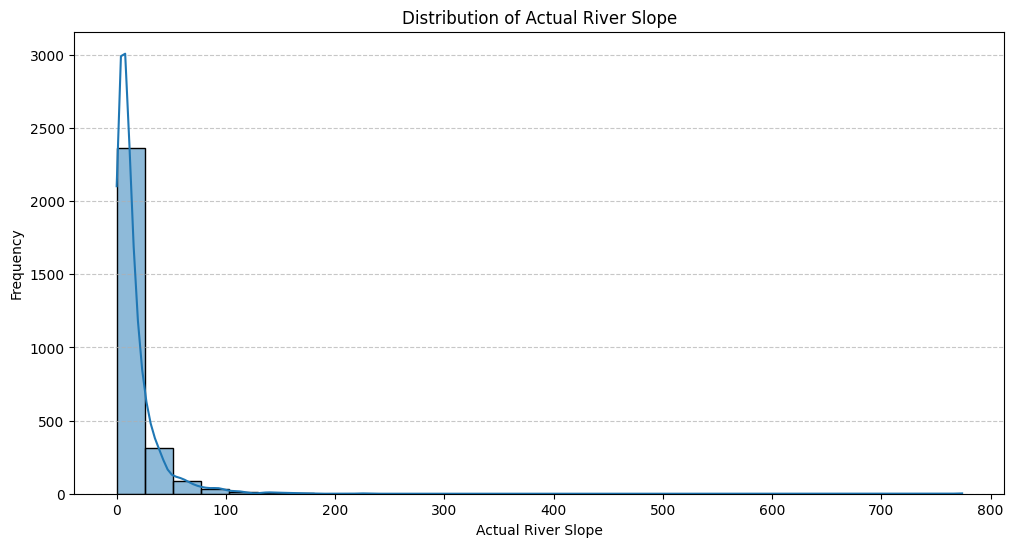

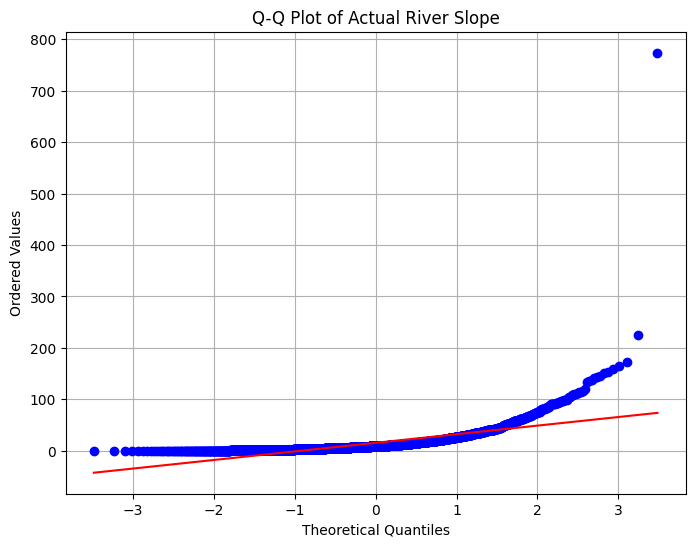


Shapiro-Wilk Test for Actual River Slope:
  Statistic = 0.4802, p-value = 0.0000
  (Reject H0: Data does not look Gaussian/normal)


In [13]:
print("\n--- Analysis of 'actual_river_slope' ---")

if 'Actual_river_slope' in df2.columns:
    slope_data = df2['Actual_river_slope']

    print("Column 'Actual_river_slope' found. Proceeding with analysis.")

    # 1. Visualize distribution using a histogram
    plt.figure(figsize=(12, 6))
    sns.histplot(slope_data, kde=True, bins=30)
    plt.title('Distribution of Actual River Slope')
    plt.xlabel('Actual River Slope')
    plt.ylabel('Frequency')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    # 2. Visualize distribution using a Q-Q plot
    plt.figure(figsize=(8, 6))
    stats.probplot(slope_data, dist="norm", plot=plt)
    plt.title('Q-Q Plot of Actual River Slope')
    plt.xlabel('Theoretical Quantiles')
    plt.ylabel('Ordered Values')
    plt.grid(True)
    plt.show()

    # 3. Formally test its normality using the Shapiro-Wilk test
    shapiro_stat, shapiro_p = stats.shapiro(slope_data)
    print(f"\nShapiro-Wilk Test for Actual River Slope:")
    print(f"  Statistic = {shapiro_stat:.4f}, p-value = {shapiro_p:.4f}")
    if shapiro_p > 0.05:
        print("  (Fail to reject H0: Data looks Gaussian/normal)")
    else:
        print("  (Reject H0: Data does not look Gaussian/normal)")
else:
    print("Column 'Actual_river_slope' not found in df2. Skipping this part of the analysis.")


## 4. Central Limit Theorem with `Actual_river_slope`

Finally, we illustrate the **Central Limit Theorem (CLT)** using `Actual_river_slope`:

1. Use the `Actual_river_slope` values in `df2` as the population.
2. Draw **100 random samples** *with replacement*, each with an intended size of **2000** observations.
   - If there are fewer than 2000 observations available, we adjust the sample size down to the maximum available.
3. For each sample, compute the **sample mean**, and collect these 100 means in a new series.
4. Analyze the distribution of sample means:
   - Plot a histogram (optionally with a KDE curve) of the 100 means.
   - Run Shapiro–Wilk on the 100 mean values to test their normality.

We then compare:

- The original distribution of `Actual_river_slope`.
- The distribution of the sample means.

We expect the sample means to be closer to a normal distribution, which demonstrates the Central Limit Theorem.



--- Demonstrating the Central Limit Theorem ---


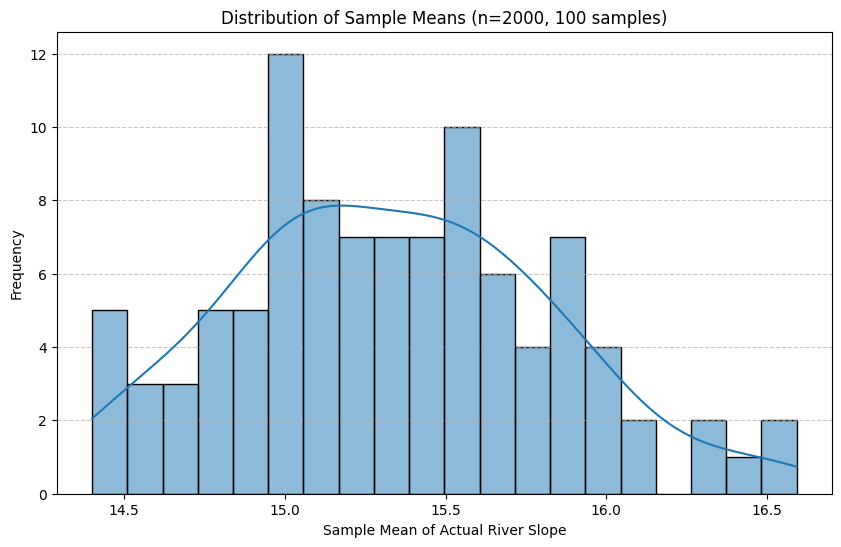


Shapiro-Wilk Test for Distribution of Sample Means:
  Statistic = 0.9861, p-value = 0.3770
  (Fail to reject H0: Sample means distribution looks Gaussian/normal)


In [14]:
print("\n--- Demonstrating the Central Limit Theorem ---")

if 'Actual_river_slope' in df2.columns:
    slope_data = df2['Actual_river_slope']

    # Parameters for resampling
    num_samples = 100
    sample_size = 2000

    # Ensure we have enough data to sample from
    if len(slope_data) < sample_size:
        print(f"Warning: Not enough data points ({len(slope_data)}) in 'Actual_river_slope' for sample size {sample_size}. Adjusting sample size.")
        sample_size = len(slope_data)

    if sample_size < 2:
        print("Not enough data to perform resampling for CLT demonstration.")
    else:
        sample_means = []
        for _ in range(num_samples):
            # Take a random sample with replacement
            sample = np.random.choice(slope_data, size=sample_size, replace=True)
            sample_means.append(np.mean(sample))

        # Convert to a pandas Series for easier plotting and analysis
        sample_means_series = pd.Series(sample_means)

        # 1. Visualize the distribution of sample means with a histogram
        plt.figure(figsize=(10, 6))
        sns.histplot(sample_means_series, kde=True, bins=20)
        plt.title(f'Distribution of Sample Means (n={sample_size}, {num_samples} samples)')
        plt.xlabel('Sample Mean of Actual River Slope')
        plt.ylabel('Frequency')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.show()

        # 2. Test its normality using the Shapiro-Wilk test
        # Shapiro-Wilk test is only valid for N < 5000
        if len(sample_means_series) < 5000:
            shapiro_stat_clt, shapiro_p_clt = stats.shapiro(sample_means_series)
            print(f"\nShapiro-Wilk Test for Distribution of Sample Means:")
            print(f"  Statistic = {shapiro_stat_clt:.4f}, p-value = {shapiro_p_clt:.4f}")
            if shapiro_p_clt > 0.05:
                print("  (Fail to reject H0: Sample means distribution looks Gaussian/normal)")
            else:
                print("  (Reject H0: Sample means distribution does not look Gaussian/normal)")
        else:
            print("\nShapiro-Wilk test not performed for sample means distribution as N >= 5000.")
            print("Consider visual inspection or other normality tests for larger sample sizes.")
else:
    print("Column 'Actual_river_slope' not found in df2. Skipping Central Limit Theorem demonstration.")

## 5. Summary of findings

Here we bring together the main results from the exercise:

- **Temperature and Brown Trout (whole dataset):**  
  Describe whether Brown Trout tends to occur at lower or higher `temp_ann` and whether the difference between presence and absence is large or small.

- **Minho vs Tagus effect sizes:**  
  Report the Cohen’s d (and/or t-statistic) for each catchment, and state which catchment shows the stronger temperature–presence relationship, or if they are similar.

- **Normality of `Actual_river_slope`:**  
  Summarize the histogram, Q–Q plot, and Shapiro–Wilk test result. State whether normality is a reasonable assumption.

- **Central Limit Theorem demonstration:**  
  Comment on how the distribution of sample means compares to the original `Actual_river_slope` distribution and how this supports the CLT (sample means tend to be approximately normal, even when the original variable is not).
